In [1]:
import zipfile
import os
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from google.colab import files

In [2]:

uploaded = files.upload()

Saving images.zip to images.zip


In [10]:

with zipfile.ZipFile("images.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Files extracted to 'dataset/' folder")

Files extracted to 'dataset/' folder


In [11]:
import os
dataset_path = "/content/dataset"
print(os.listdir(dataset_path))


['16', '0', '5', '8', '4', '3', '7', '15', '1', '11', '2', '9', 'happy.jpeg', '10', '14', '12', '13', '6', '18', '17']


In [12]:

num_to_emotion = {
    '0': 'anger',
    '1': 'contempt',
    '2': 'disgust',
    '3': 'fear',
    '4': 'happy',
    '5': 'neutral',
    '6': 'sad',
    '7': 'surprised'

}


In [13]:
X = []
y = []

for folder_num in os.listdir('dataset'):
    folder_path = os.path.join('dataset', folder_num)
    if not os.path.isdir(folder_path):
        continue
    emotion_name = num_to_emotion.get(folder_num)
    if emotion_name is None:
        continue
    label_idx = list(num_to_emotion.values()).index(emotion_name)

    for img_file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_file)
        try:
            img = Image.open(img_path).convert('L')
            img = img.resize((48,48))
            X.append(np.array(img)/255.0)
            y.append(label_idx)
        except:
            pass

X = np.array(X).reshape(-1,48,48,1)
y = to_categorical(y, num_classes=len(num_to_emotion))
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (64, 48, 48, 1)
y shape: (64, 8)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (51, 48, 48, 1) (51, 8)
Test shape: (13, 48, 48, 1) (13, 8)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax')  # 8 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,714,056 (6.54 MB)

 Trainable params: 1,714,056 (6.54 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15, batch_size=8)


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.0563 - loss: 2.1073 - val_accuracy: 0.1538 - val_loss: 2.0448
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.2382 - loss: 2.0287 - val_accuracy: 0.5385 - val_loss: 1.9951
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.4983 - loss: 1.9108 - val_accuracy: 0.8462 - val_loss: 1.7115
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.4765 - loss: 1.6758 - val_accuracy: 1.0000 - val_loss: 1.2526
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7721 - loss: 1.1250 - val_accuracy: 0.9231 - val_loss: 0.8144
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7610 - loss: 0.8810 - val_accuracy: 1.0000 - val_loss: 0.3673
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8781 - loss: 0.5711 - val_accuracy: 1.0000 - val_loss: 0.3039
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8461 - loss: 0.5227 - val_accuracy: 1.0000 - val_loss: 0.1314

In [17]:
model.save("emotion_model.h5")
print("Model saved as emotion_model.h5")


Model saved as emotion_model.h5


#testing

In [38]:
from PIL import Image
import numpy as np


img = Image.open("/content/angry.jpg").convert('L')  # grayscale
img = img.resize((48,48))

img_array = np.array(img)/255.0
img_array = img_array.reshape(1,48,48,1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


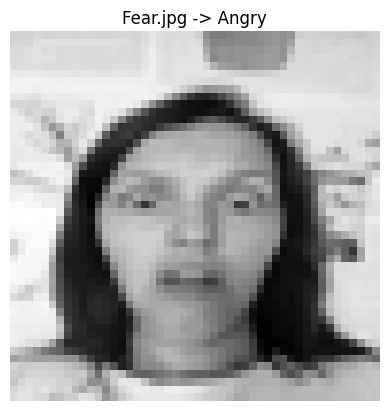

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


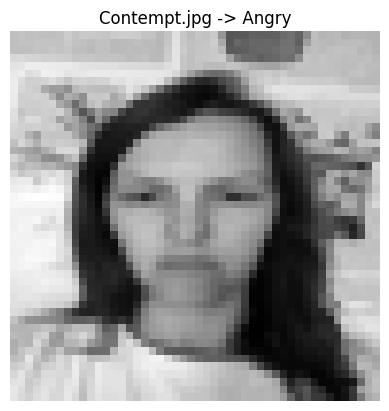

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


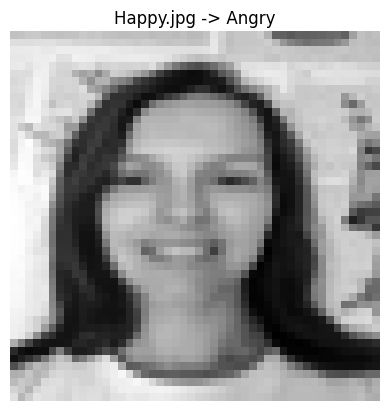

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


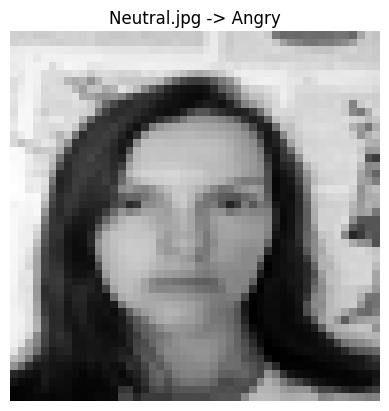

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


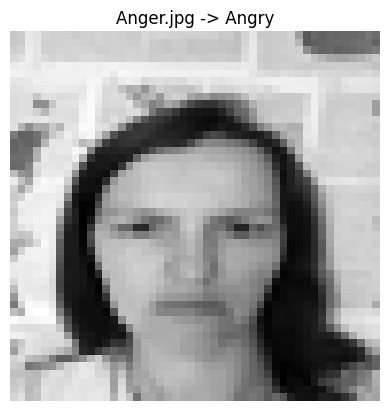

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


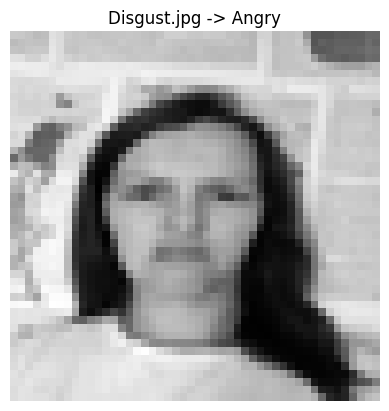

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


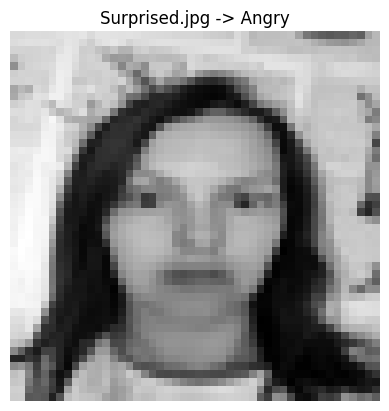

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


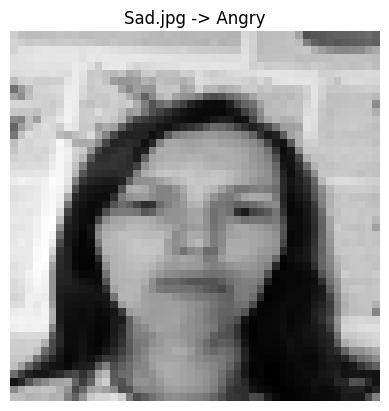

In [39]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Define emotions list
emotions = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

image_folder = "dataset/0"  # change folder name if needed

if os.path.exists(image_folder):
    for img_file in os.listdir(image_folder):
        img_path = os.path.join(image_folder, img_file)
        try:
            # Preprocess image
            img = Image.open(img_path).convert('L').resize((48, 48))
            img_array = np.array(img) / 255.0
            img_array = img_array.reshape(1, 48, 48, 1)

            # Prediction
            pred = model.predict(img_array)
            emotion_idx = np.argmax(pred)

            # Show image with label
            plt.imshow(img, cmap="gray")
            plt.title(f"{img_file} -> {emotions[emotion_idx]}")
            plt.axis("off")
            plt.show()

        except Exception as e:
            print(f"Skipping {img_file}, error: {e}")
else:
    print("❌ Folder not found. Check dataset path.")




In [40]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(gray, (48,48))
    img_array = img.reshape(1,48,48,1)/255.0

    pred = model.predict(img_array)
    emotion_idx = np.argmax(pred)
    label = emotions[emotion_idx]

    cv2.putText(frame, label, (50,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow('Emotion Detection', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
